In [1]:
library(ggplot2)
library(tidyverse)
library(ggpubr)

── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
indir = '../'
outdir = '../plots'

In [3]:
options(repr.plot.width=45/25.4,repr.plot.height=45/25.4,repr.plot.res=400)

In [5]:
data = read.csv(paste0(indir,'/plotting_for_supplementary/example_Etl4/data_60kb_bin_by_cell_for_Etl4.csv'))

In [6]:
data2 = data[c('subclass_label','X5hmCG_chr2_19690000_19750000', 'X5mCG_chr2_19690000_19750000', 'ENSMUSG00000036617.16')]

In [8]:
data3 = data2[data2$'subclass_label' %in% c('OB-out Frmd7 Gaba', 'STR D1 Gaba', 'L6 CT CTX Glut', 'L5 NP CTX Glut'),]
colnames(data3) = c('subclass_label', 'X5hmCG', 'X5mCG', 'RNA')
data3$'true5mCG'=pmax(data3$'X5mCG'-data3$'X5hmCG', 0)
data3$'subclass_label' <- factor(data3$'subclass_label', levels = c('L5 NP CTX Glut', 'L6 CT CTX Glut', 'STR D1 Gaba', 'OB-out Frmd7 Gaba'))

In [9]:
head(data3)

,subclass_label,X5hmCG,X5mCG,RNA,true5mCG
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
4,L6 CT CTX Glut,0.3571429,0.8333333,2.9919523,0.4761904
10,L6 CT CTX Glut,0.0000000,NA,1.6233083,NA
29,STR D1 Gaba,0.2372881,0.9339623,2.0861011,0.6966742
39,L6 CT CTX Glut,NA,NA,3.5159552,NA
40,L6 CT CTX Glut,0.2467533,0.8282828,2.6897757,0.5815296
42,STR D1 Gaba,0.2307692,0.8068182,0.1442589,0.5760490


In [10]:
my_comparisons = list(c('L5 NP CTX Glut', 'L6 CT CTX Glut'),
                       c('L6 CT CTX Glut', 'STR D1 Gaba'),
                      c('STR D1 Gaba', 'OB-out Frmd7 Gaba'))

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


agg_record_708437281 
                   2

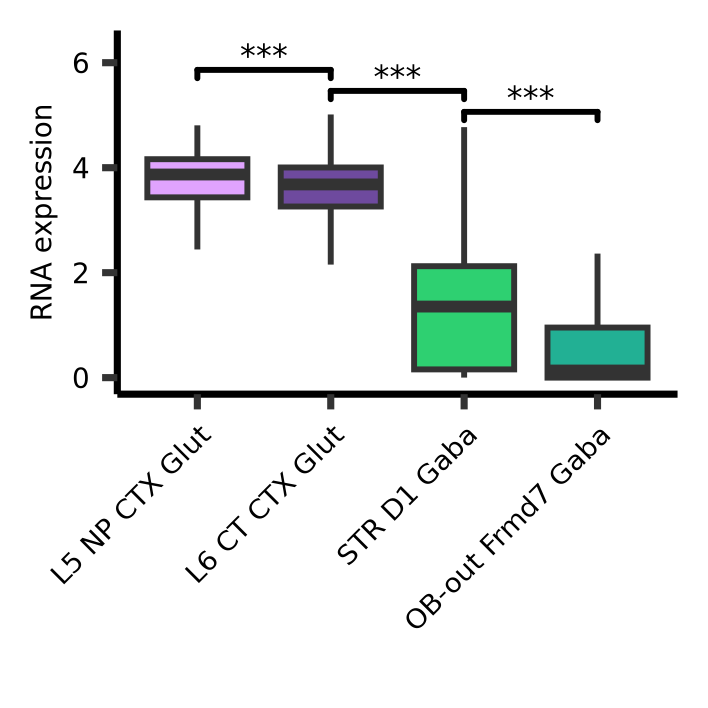

In [12]:
pdf(paste0(outdir, '/08_barplot_RNA.pdf'), width=45/25.4,height=45/25.4, family="ArialMT")

p <- ggplot(data=data3, aes(x=subclass_label, group=subclass_label,y=RNA,fill=subclass_label))+
geom_boxplot(outliers = FALSE)+
scale_fill_manual(values = c('L5 NP CTX Glut'="#e0a3fe", 'L6 CT CTX Glut'="#6e4a9e", 'STR D1 Gaba'="#2ed071", "OB-out Frmd7 Gaba"="#22b094")) + # Set custom colors
theme_bw()+
labs(x='',y='RNA expression')+
theme(legend.position="none",
legend.title = element_text(size = 5),  # Change legend title size
legend.text = element_text(size = 5),   # Change legend text size
plot.title = element_text(hjust = 0.5,family="ArialMT"),
title = element_text(size=5,hjust = 0.5,family="ArialMT"),
axis.title.x = element_text(color="black", size=5,family="ArialMT"),
axis.title.y = element_text(color="black", size=5,family="ArialMT"),
axis.text.x = element_text(color="black", size=5,family="ArialMT", angle = 45, hjust = 1),
axis.text.y = element_text(color="black", size=5,family="ArialMT"),
axis.line=element_line(size=0.6),
axis.ticks=element_line(size=0.6),
panel.border=element_blank(),
panel.grid=element_blank())+
geom_signif(  comparisons = my_comparisons,  map_signif_level = TRUE, test = "wilcox.test", y_position = c(5.6,5.2,4.8), textsize = 2)+
ylim(c(0,6.3))
print(p)
dev.off()
print(p)

In [13]:
data3 %>% group_by(subclass_label) %>% summarise(mean_value = mean(RNA, na.rm = TRUE))

subclass_label,mean_value
<fct>,<dbl>
L5 NP CTX Glut,3.6989346
L6 CT CTX Glut,3.5379806
STR D1 Gaba,1.2771718
OB-out Frmd7 Gaba,0.6671841


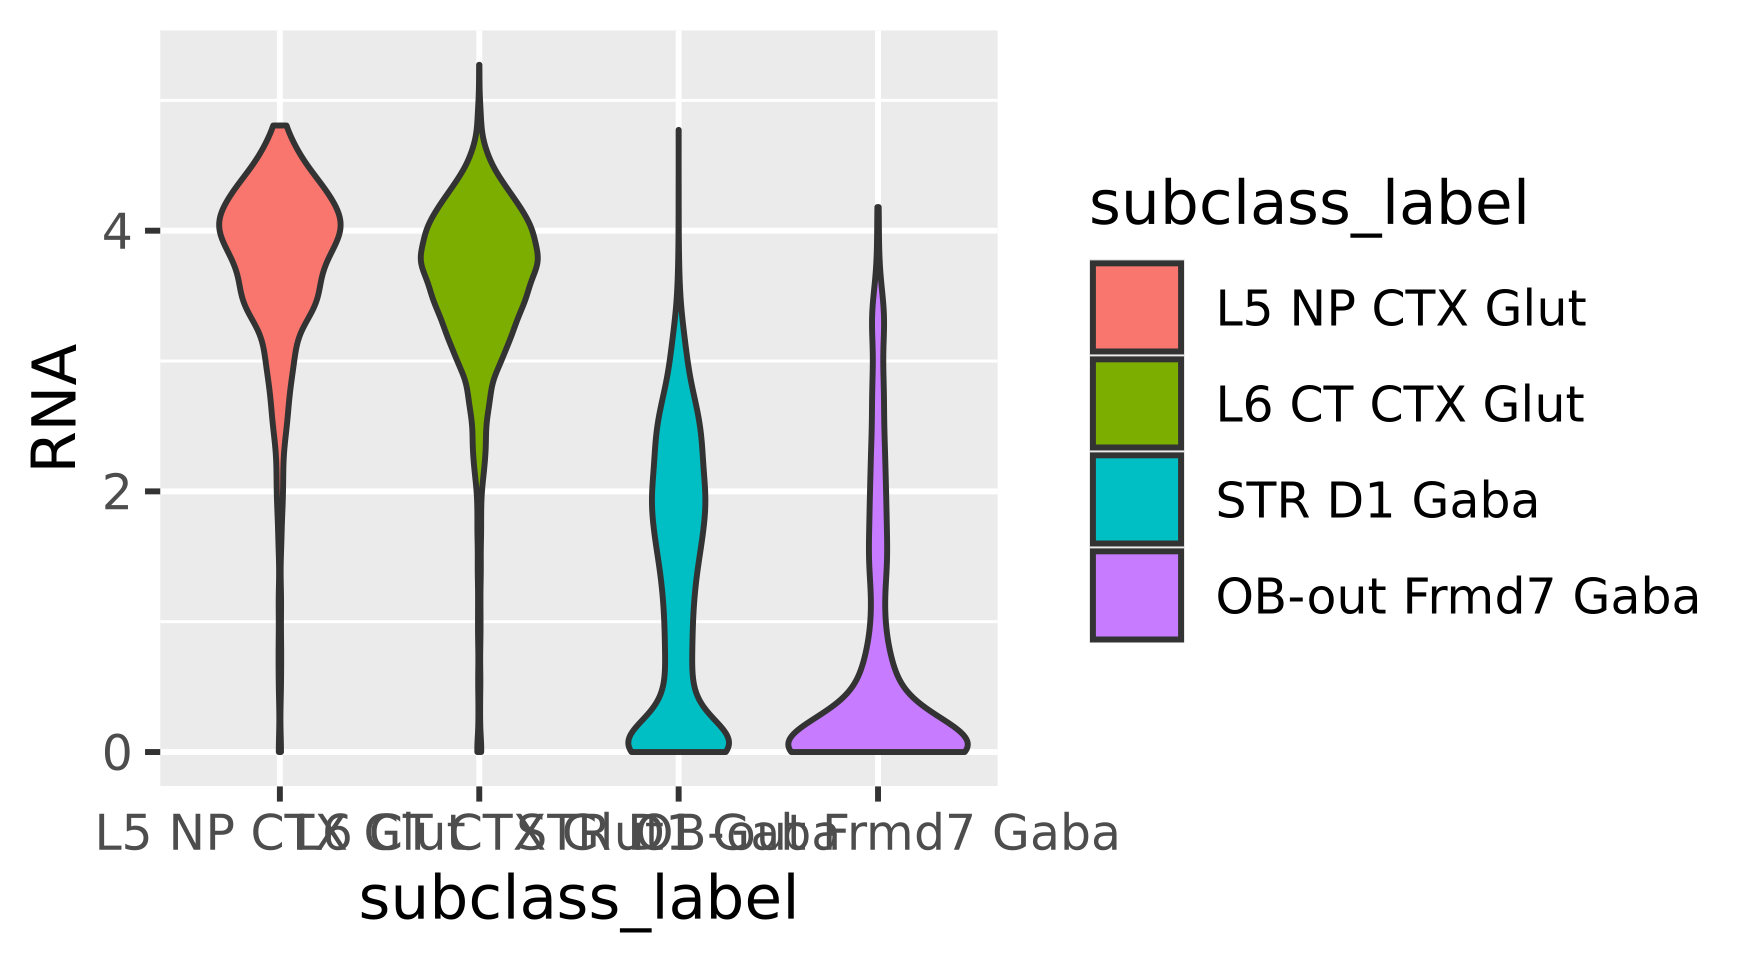

In [14]:
options(repr.plot.width=4.4,repr.plot.height=2.4,repr.plot.res=400)
ggplot(data=data3, aes(x=subclass_label, group=subclass_label,y=RNA,fill=subclass_label))+
geom_violin()

Warning message:
“Removed 1464 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1464 rows containing non-finite outside the scale range (`stat_signif()`).”


agg_record_287977231 
                   2

Warning message:
“Removed 1464 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1464 rows containing non-finite outside the scale range (`stat_signif()`).”


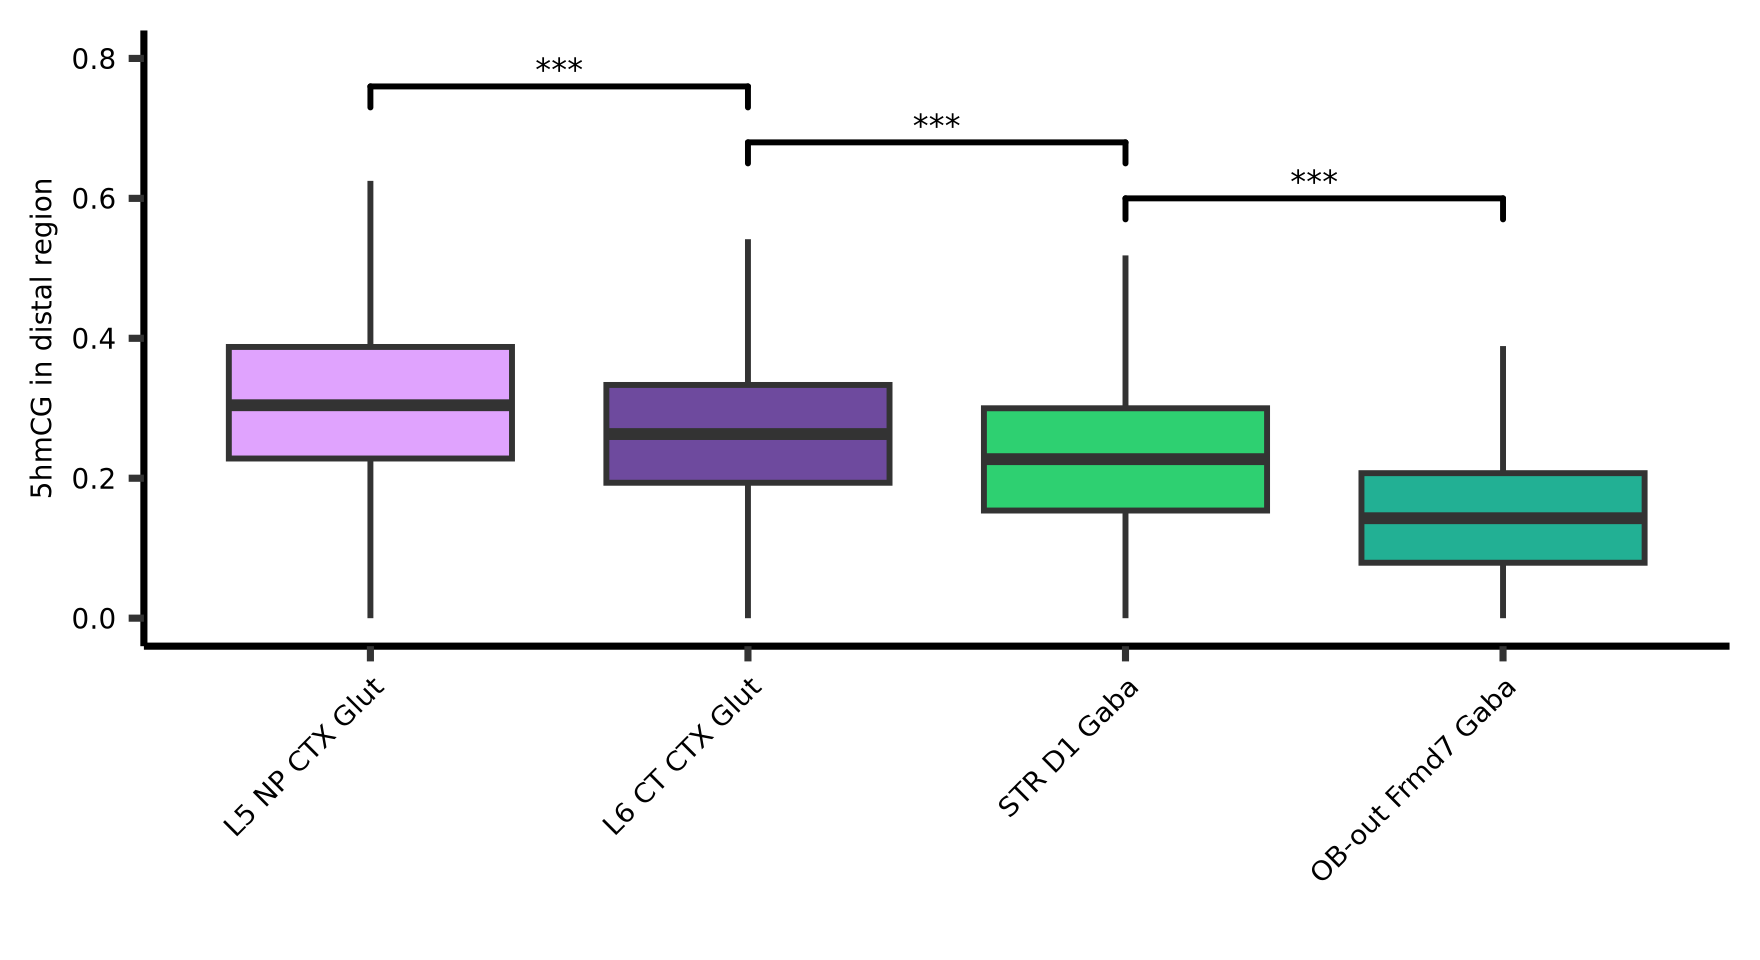

In [16]:
pdf(paste0(outdir, '/08_barplot_5hmCG.pdf'), width=45/25.4,height=45/25.4, family="ArialMT")

p <- ggplot(data=data3, aes(x=subclass_label, group=subclass_label,y=X5hmCG,fill=subclass_label))+
geom_boxplot(outliers = FALSE)+
scale_fill_manual(values = c('L5 NP CTX Glut'="#e0a3fe", 'L6 CT CTX Glut'="#6e4a9e", 'STR D1 Gaba'="#2ed071", "OB-out Frmd7 Gaba"="#22b094")) + # Set custom colors
theme_bw()+
labs(x='',y='5hmCG in distal region')+
theme(legend.position="none",
legend.title = element_text(size = 5),  # Change legend title size
legend.text = element_text(size = 5),   # Change legend text size
plot.title = element_text(hjust = 0.5,family="ArialMT"),
title = element_text(size=5,hjust = 0.5,family="ArialMT"),
axis.title.x = element_text(color="black", size=5,family="ArialMT"),
axis.title.y = element_text(color="black", size=5,family="ArialMT"),
axis.text.x = element_text(color="black", size=5,family="ArialMT", angle = 45, hjust = 1),
axis.text.y = element_text(color="black", size=5,family="ArialMT"),
axis.line=element_line(size=0.6),
axis.ticks=element_line(size=0.6),
panel.border=element_blank(),
panel.grid=element_blank())+
geom_signif(  comparisons = my_comparisons,  map_signif_level = TRUE, test = "wilcox.test", y_position = c(0.71,0.63,0.55), textsize = 2)+
ylim(c(0,0.8))

print(p)
dev.off()
print(p)

Warning message:
“Removed 1426 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1426 rows containing non-finite outside the scale range (`stat_signif()`).”


agg_record_651786886 
                   2

Warning message:
“Removed 1426 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1426 rows containing non-finite outside the scale range (`stat_signif()`).”


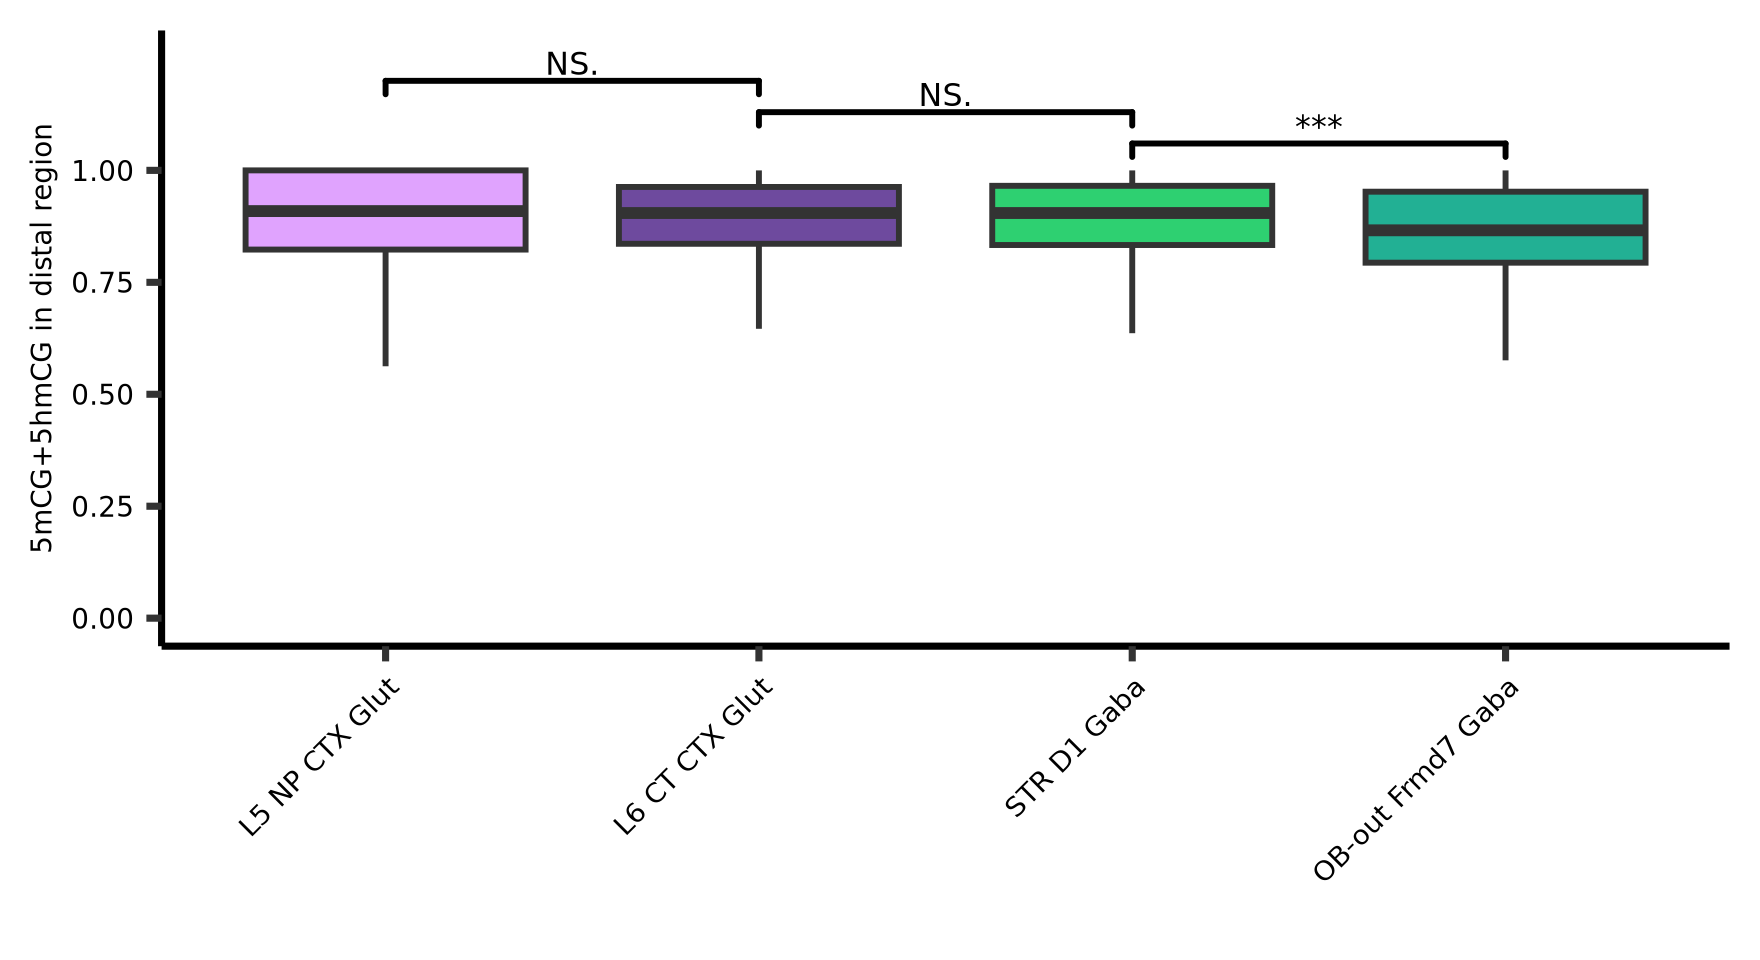

In [20]:
pdf(paste0(outdir, '/08_barplot_total5mCG.pdf'), width=45/25.4,height=45/25.4, family="ArialMT")

p <- ggplot(data=data3, aes(x=subclass_label, group=subclass_label,y=X5mCG,fill=subclass_label))+
geom_boxplot(outliers = FALSE)+
scale_fill_manual(values = c('L5 NP CTX Glut'="#e0a3fe", 'L6 CT CTX Glut'="#6e4a9e", 'STR D1 Gaba'="#2ed071", "OB-out Frmd7 Gaba"="#22b094")) + # Set custom colors
theme_bw()+
labs(x='',y='5mCG+5hmCG in distal region')+
theme(legend.position="none",
legend.title = element_text(size = 5),  # Change legend title size
legend.text = element_text(size = 5),   # Change legend text size
plot.title = element_text(hjust = 0.5,family="ArialMT"),
title = element_text(size=5,hjust = 0.5,family="ArialMT"),
axis.title.x = element_text(color="black", size=5,family="ArialMT"),
axis.title.y = element_text(color="black", size=5,family="ArialMT"),
axis.text.x = element_text(color="black", size=5,family="ArialMT", angle = 45, hjust = 1),
axis.text.y = element_text(color="black", size=5,family="ArialMT"),
axis.line=element_line(size=0.6),
axis.ticks=element_line(size=0.6),
panel.border=element_blank(),
panel.grid=element_blank())+
geom_signif(  comparisons = my_comparisons,  map_signif_level = TRUE, test = "wilcox.test", y_position = c(1.15,1.08,1.01), textsize = 2,family="ArialMT")+
scale_y_continuous(limits = c(0, 1.25), breaks = seq(0, 1, by = 0.25))

print(p)
dev.off()
print(p)

Warning message:
“Removed 1774 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1774 rows containing non-finite outside the scale range (`stat_signif()`).”


agg_record_296443860 
                   2

Warning message:
“Removed 1774 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1774 rows containing non-finite outside the scale range (`stat_signif()`).”


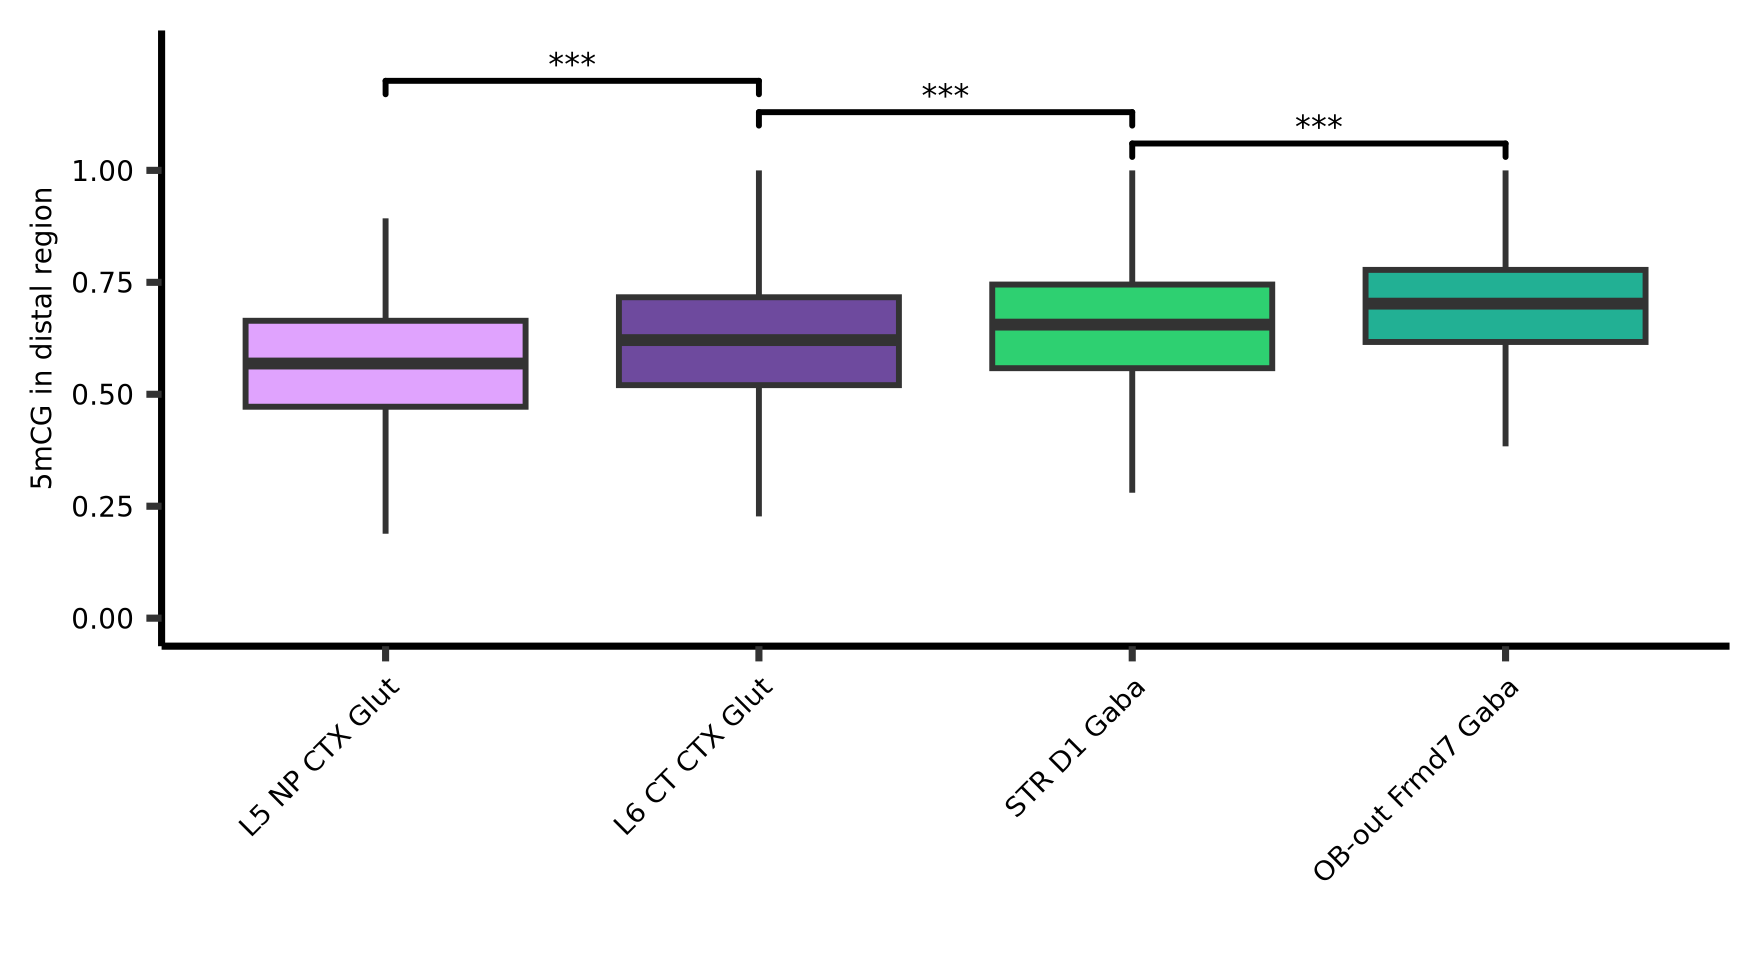

In [21]:
pdf(paste0(outdir, '/08_barplot_true5mCG.pdf'), width=45/25.4,height=45/25.4, family="ArialMT")

p <- ggplot(data=data3, aes(x=subclass_label, group=subclass_label,y=true5mCG,fill=subclass_label))+
geom_boxplot(outliers = FALSE)+
scale_fill_manual(values = c('L5 NP CTX Glut'="#e0a3fe", 'L6 CT CTX Glut'="#6e4a9e", 'STR D1 Gaba'="#2ed071", "OB-out Frmd7 Gaba"="#22b094")) + # Set custom colors
theme_bw()+
labs(x='',y='5mCG in distal region')+
theme(legend.position="none",
legend.title = element_text(size = 5),  # Change legend title size
legend.text = element_text(size = 5),   # Change legend text size
plot.title = element_text(hjust = 0.5,family="ArialMT"),
title = element_text(size=5,hjust = 0.5,family="ArialMT"),
axis.title.x = element_text(color="black", size=5,family="ArialMT"),
axis.title.y = element_text(color="black", size=5,family="ArialMT"),
axis.text.x = element_text(color="black", size=5,family="ArialMT", angle = 45, hjust = 1),
axis.text.y = element_text(color="black", size=5,family="ArialMT"),
axis.line=element_line(size=0.6),
axis.ticks=element_line(size=0.6),
panel.border=element_blank(),
panel.grid=element_blank())+
geom_signif(  comparisons = my_comparisons,  map_signif_level = TRUE, test = "wilcox.test", y_position = c(1.15,1.08,1.01), textsize = 2)+
scale_y_continuous(limits = c(0, 1.25), breaks = seq(0, 1, by = 0.25))

print(p)
dev.off()
print(p)